<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap1_generative_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.1 画像の生成

オープンソースに diffusers というものがある。SOTA（拡散モデル）にアクセスできる。
拡散モデルは画像や音声にノイズを加える、あるいは逆にノイズを取り除くことで画像などを複製するもの。

In [ ]:
%pip install genaibook

In [ ]:
from genaibook.core import get_device

device = get_device()
print(f"Using device: {device}")

Using device: cuda


diffusers には StableDiffusionPipeline という便利で高レベルなラッパーがあるので今回はこれを使う。

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    variant="fp16"
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

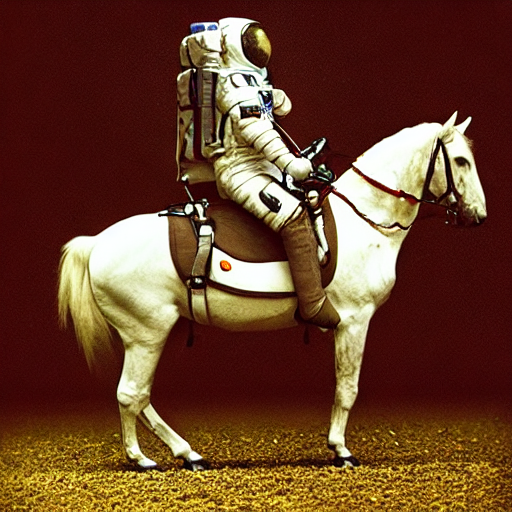

In [ ]:
prompt = "a photograph of an astronaut riding a horse"
pipe(prompt).images[0]

同じプロンプトでも異なる画像が生成されるのは、拡散プロセスが本質的に確率的であるからである。
シード値（seed）を設定して、このランダム性を制御することも可能。

In [ ]:
import torch
torch.manual_seed(0)

1.2 テキストの生成

transformers ライブラリを使う。
transformers はさまざまな抽象化レイヤーを持っている。
とりわけ pipeline 関数は、テキスト分類だろうがなんだろうが、とりあえずこれを使っておけばOKという関数。

In [ ]:
from transformers import pipeline

classifier = pipeline("text-classification", device=device)
classifier("This movie is disgutingly good!")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.9953525066375732}]

テキスト生成のパターン

In [ ]:
from transformers import set_seed

# コード実行時に毎回同じ結果が得られるように明示的にシードを設定する
set_seed(10)

In [ ]:
generator = pipeline("text-generation", device=device)
prompt = "It was a dark and stormy"
generator(prompt)[0]["generated_text"]

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


"It was a dark and stormy night. No lights were out but people were walking down the street, and it was really cold, and there was no food available. It was very hot, and I heard the sound of people running. And then my mother was running. She was standing on the edge of the street, and people were running, and everyone was running. I couldn't hear who it was, and no one else was. So I tried to grab my bag and pull up the hood and go down to the sidewalk where I'd been standing, and there wasn't a big space there. I was in a little corner, and I think I walked into a little corner, and then I thought maybe I was going to get hit by someone, and I was just in that little corner, and I hit my head on the sidewalk and I was just crying. And then I had to walk to the doctor and I was just screaming. I had to run back to the hospital and I was just screaming. So, I thought it was all in my head, and I went to the ER. My doctor was in there, and I was just crying, and so I got up, and I just

1.3 サウンドクリップの生成

transformer の pipeline を使って、Meta が公開した MusicGen のスモール版で音楽を生成してみる。

In [ ]:
pipe = pipeline("text-to-audio", model="facebook/musicgen-small", device=device)
data = pipe("electric rock solo, very intense")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda


In [ ]:
print(data)

{'audio': array([[[-0.08888735, -0.09211662, -0.06041147, ...,  0.18321162,
          0.14789942,  0.18424182]]], dtype=float32), 'sampling_rate': 32000}


↑の細かいことは後の章で解説する

In [ ]:
import IPython.display as ipd

display(ipd.Audio(data["audio"][0],rate=data["sampling_rate"]))

test